# 🚀 Actividad Computacional — Visualizador de Bases

## Proyecto: Herramienta para Visualizar Cambios de Base en $\mathbb{R}^2$

---

En esta actividad construirás una **herramienta de visualización** que muestra el mismo vector
en múltiples bases simultáneamente, y analiza cómo las transformaciones lineales se simplifican
al elegir la base adecuada.

### 🎯 Objetivos

- Implementar en Python las operaciones de cambio de base.
- Visualizar la cuadrícula de dos sistemas de referencia en el mismo plano.
- Construir una tabla comparativa de coordenadas.
- Demostrar con un ejemplo concreto por qué la base de autovectores es especial.

### 🧩 Estructura del proyecto

| Celda | Contenido |
|:---:|:---|
| 2–3 | Clase `BasisVisualizer` — implementación |
| 4–5 | Demostración 1: vector en dos bases |
| 6–7 | Demostración 2: tabla comparativa de coordenadas |
| 8–9 | Demostración 3: transformación en base vs. en base de autovectores |
| 10–11 | Demostración 4: grilla completa con múltiples vectores |
| 12 | Reflexión y conclusiones |

## 🔧 Parte 1: Implementar la Clase `BasisVisualizer`

Construiremos una clase que encapsula las operaciones de cambio de base y las visualizaciones.

**Interfaz:**
```python
bv = BasisVisualizer(b1, b2)         # base = {b1, b2}
bv.to_basis(v)                        # convierte v a coordenadas en la base
bv.from_basis(v_B)                    # convierte de coordenadas base a estándar
bv.transform_matrix(A)                # calcula A en la nueva base
bv.draw(v_list, ax)                   # dibuja la cuadrícula y los vectores
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.patches import FancyArrowPatch

class BasisVisualizer:
    """Herramienta para visualizar bases y cambios de coordenadas en R²."""

    def __init__(self, b1, b2, name='B'):
        self.b1 = np.array(b1, dtype=float)
        self.b2 = np.array(b2, dtype=float)
        self.name = name
        self.P = np.column_stack([self.b1, self.b2])
        if abs(np.linalg.det(self.P)) < 1e-10:
            raise ValueError("Los vectores no forman una base válida (det = 0).")
        self.P_inv = np.linalg.inv(self.P)

    def to_basis(self, v):
        """Convierte un vector en coordenadas estándar a coordenadas en la base."""
        return self.P_inv @ np.array(v)

    def from_basis(self, v_B):
        """Convierte coordenadas en la base a coordenadas estándar."""
        return self.P @ np.array(v_B)

    def transform_matrix(self, A):
        """Calcula la representación de la transformación A en esta base."""
        return self.P_inv @ np.array(A) @ self.P

    def draw_grid(self, ax, xlim=(-1, 5), ylim=(-1, 5), color='blue', alpha=0.2, label=''):
        """Dibuja la cuadrícula del sistema de coordenadas de esta base."""
        for k in np.arange(-8, 9, 1):
            # Líneas paralelas a b1
            s = k * self.b2
            ax.plot([s[0]-8*self.b1[0], s[0]+8*self.b1[0]],
                    [s[1]-8*self.b1[1], s[1]+8*self.b1[1]],
                    color=color, lw=0.5, alpha=alpha)
            # Líneas paralelas a b2
            s2 = k * self.b1
            ax.plot([s2[0]-8*self.b2[0], s2[0]+8*self.b2[0]],
                    [s2[1]-8*self.b2[1], s2[1]+8*self.b2[1]],
                    color=color, lw=0.5, alpha=alpha)

        # Ejes de la base
        scale = max(abs(xlim[1]-xlim[0]), abs(ylim[1]-ylim[0])) / 2
        ax.quiver(0,0,self.b1[0]*scale,self.b1[1]*scale,
                  angles='xy',scale_units='xy',scale=1,
                  color=color,width=0.01,alpha=0.7)
        ax.quiver(0,0,self.b2[0]*scale,self.b2[1]*scale,
                  angles='xy',scale_units='xy',scale=1,
                  color=color,width=0.01,alpha=0.7,linestyle='--')
        ax.text(self.b1[0]*scale+0.05, self.b1[1]*scale+0.05,
                f'$\\mathbf{{b}}_1$', color=color, fontsize=10)
        ax.text(self.b2[0]*scale+0.05, self.b2[1]*scale+0.05,
                f'$\\mathbf{{b}}_2$', color=color, fontsize=10)

    def info(self):
        print(f"Base {self.name}:")
        print(f"  b1 = {self.b1}")
        print(f"  b2 = {self.b2}")
        print(f"  det(P) = {np.linalg.det(self.P):.4f}")

print("✅ Clase BasisVisualizer definida correctamente.")

# Prueba rápida
bv = BasisVisualizer([2, 1], [-1, 2], name='B')
bv.info()
v = np.array([3., 2.])
v_B = bv.to_basis(v)
print(f"\nVector v={v} en base B: {np.round(v_B, 4)}")
print(f"Recuperar: {np.round(bv.from_basis(v_B), 4)} — igual: {np.allclose(bv.from_basis(v_B), v)}")

✅ Clase BasisVisualizer definida correctamente.
Base B:
  b1 = [2. 1.]
  b2 = [-1.  2.]
  det(P) = 5.0000

Vector v=[3. 2.] en base B: [1.6 0.2]
Recuperar: [3. 2.] — igual: True


## 📊 Parte 2: Demostración 1 — Mismo Vector, Dos Bases

Visualizamos el vector $\mathbf{v} = (3, 2)$ en la base estándar y en la base
$\mathcal{B} = \{(2,1)/\sqrt{5},\, (-1,2)/\sqrt{5}\}$, con la cuadrícula de cada sistema.

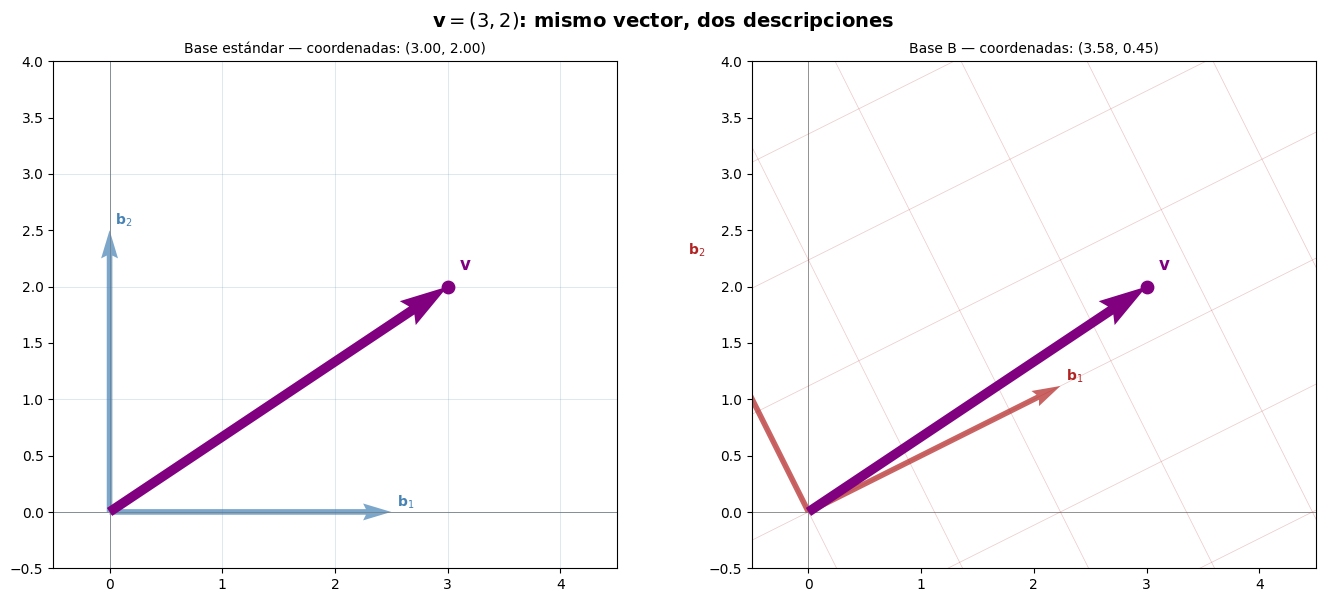

Base estándar: v = [3. 2.]
Base B:        v = [3.5777 0.4472]


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Crear dos visualizadores
bv_std = BasisVisualizer([1, 0], [0, 1], name='Estándar')
bv_B   = BasisVisualizer([2/np.sqrt(5), 1/np.sqrt(5)], [-1/np.sqrt(5), 2/np.sqrt(5)], name='B')

v = np.array([3., 2.])
v_std = bv_std.to_basis(v)   # = (3, 2)
v_B   = bv_B.to_basis(v)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'$\\mathbf{{v}}=(3,2)$: mismo vector, dos descripciones', fontsize=14, fontweight='bold')

for ax, bv, coords, title, gcol in [
    (axes[0], bv_std, v_std, f'Base estándar — coordenadas: ({v_std[0]:.2f}, {v_std[1]:.2f})', 'steelblue'),
    (axes[1], bv_B, v_B, f'Base B — coordenadas: ({v_B[0]:.2f}, {v_B[1]:.2f})', 'firebrick')
]:
    ax.set_xlim(-0.5, 4.5); ax.set_ylim(-0.5, 4)
    ax.set_aspect('equal'); ax.set_title(title, fontsize=10)
    ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
    bv.draw_grid(ax, xlim=(-0.5,4.5), ylim=(-0.5,4), color=gcol, alpha=0.25)
    ax.quiver(0,0,v[0],v[1],angles='xy',scale_units='xy',scale=1,
              color='purple',width=0.017,zorder=5)
    ax.scatter(*v, color='purple', s=80, zorder=10)
    ax.text(v[0]+0.1,v[1]+0.15,f'$\\mathbf{{v}}$',color='purple',fontsize=12,fontweight='bold')

plt.tight_layout(); plt.show()
print(f"Base estándar: v = {v_std}")
print(f"Base B:        v = {np.round(v_B, 4)}")

## 📊 Parte 3: Tabla Comparativa de Coordenadas

Construiremos una tabla que muestra las coordenadas de varios vectores en múltiples bases.

In [3]:
import numpy as np

# Tres bases distintas
bases = {
    'Estándar': BasisVisualizer([1, 0], [0, 1]),
    'Rotada 45°': BasisVisualizer([1/np.sqrt(2), 1/np.sqrt(2)], [-1/np.sqrt(2), 1/np.sqrt(2)]),
    'Base B': BasisVisualizer([2, 1], [0, 1]),
    'Ortogonal': BasisVisualizer([3/5, 4/5], [-4/5, 3/5]),
}

# Vectores a analizar
vectores = {
    'v1=(1,0)': np.array([1., 0.]),
    'v2=(0,1)': np.array([0., 1.]),
    'v3=(3,2)': np.array([3., 2.]),
    'v4=(1,1)': np.array([1., 1.]),
    'v5=(2,3)': np.array([2., 3.]),
}

# Encabezado
col_w = 20
header = f"{'Vector':<12}" + "".join(f"{name:<{col_w}}" for name in bases)
print(header)
print("-" * (12 + col_w * len(bases)))

for vname, v in vectores.items():
    row = f"{vname:<12}"
    for bname, bv in bases.items():
        c = bv.to_basis(v)
        row += f"({c[0]:.3f}, {c[1]:.3f})   "[:col_w]
    print(row)

print("\n💡 Observaciones:")
print("  • En base estándar, e1 y e2 tienen coordenadas (1,0) y (0,1) — trivial.")
print("  • En base rotada 45°, (1,1) tiene coordenadas (√2, 0) — se alinea con b1.")
print("  • Las coordenadas numéricas cambian, pero los vectores son siempre los mismos.")

Vector      Estándar            Rotada 45°          Base B              Ortogonal           
--------------------------------------------------------------------------------------------
v1=(1,0)    (1.000, 0.000)   (0.707, -0.707)   (0.500, -0.500)   (0.600, -0.800)   
v2=(0,1)    (0.000, 1.000)   (0.707, 0.707)   (0.000, 1.000)   (0.800, 0.600)   
v3=(3,2)    (3.000, 2.000)   (3.536, -0.707)   (1.500, 0.500)   (3.400, -1.200)   
v4=(1,1)    (1.000, 1.000)   (1.414, 0.000)   (0.500, 0.500)   (1.400, -0.200)   
v5=(2,3)    (2.000, 3.000)   (3.536, 0.707)   (1.000, 2.000)   (3.600, 0.200)   

💡 Observaciones:
  • En base estándar, e1 y e2 tienen coordenadas (1,0) y (0,1) — trivial.
  • En base rotada 45°, (1,1) tiene coordenadas (√2, 0) — se alinea con b1.
  • Las coordenadas numéricas cambian, pero los vectores son siempre los mismos.


## 📊 Parte 4: Transformación en Base Estándar vs. Base de Autovectores

Demostramos que la base de autovectores **simplifica drásticamente** la representación matricial.

Transformación A:
[[3. 1.]
 [1. 3.]]

Autovalores: λ1=2.00, λ2=4.00
Autovectores:
  p1 = [-0.7071  0.7071]
  p2 = [0.7071 0.7071]

A en base de autovectores:
[[ 2. -0.]
 [-0.  4.]]
¡Es diagonal! Los autovalores en la diagonal.


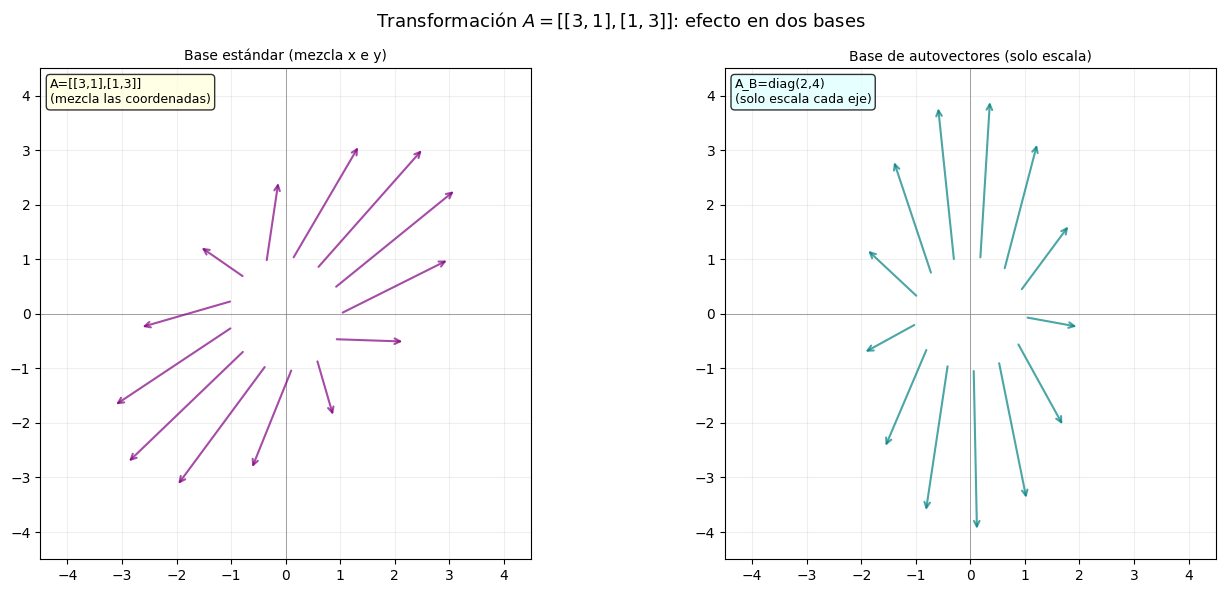

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Transformación: escalado asimétrico + mezcla
A = np.array([[3., 1.],
              [1., 3.]])

# Encontrar autovectores
eigenvalues, eigenvectors = np.linalg.eig(A)
idx = np.argsort(eigenvalues)
eigenvalues = eigenvalues[idx]; eigenvectors = eigenvectors[:, idx]

print("Transformación A:")
print(A)
print(f"\nAutovalores: λ1={eigenvalues[0]:.2f}, λ2={eigenvalues[1]:.2f}")
print(f"Autovectores:\n  p1 = {np.round(eigenvectors[:,0],4)}\n  p2 = {np.round(eigenvectors[:,1],4)}")

# Crear visualizador con base de autovectores
bv_eigen = BasisVisualizer(eigenvectors[:,0], eigenvectors[:,1], name='Autovectores')
A_eigen = bv_eigen.transform_matrix(A)
print("\nA en base de autovectores:")
print(np.round(A_eigen, 6))
print("¡Es diagonal! Los autovalores en la diagonal.")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Transformación $A = [[3,1],[1,3]]$: efecto en dos bases', fontsize=13)

angles = np.linspace(0, 2*np.pi, 13, endpoint=False)
vecs = np.array([np.cos(angles), np.sin(angles)])
Av = A @ vecs
vecs_B = np.linalg.inv(bv_eigen.P) @ vecs
Av_B = A_eigen @ vecs_B

for ax, vs, Tvs, title, col, bv in [
    (axes[0], vecs, Av, 'Base estándar (mezcla x e y)', 'purple', None),
    (axes[1], vecs_B, Av_B, 'Base de autovectores (solo escala)', 'teal', bv_eigen)
]:
    ax.set_xlim(-4.5, 4.5); ax.set_ylim(-4.5, 4.5)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(title, fontsize=10)
    for i in range(vs.shape[1]):
        ax.annotate('', xy=(Tvs[0,i],Tvs[1,i]), xytext=(vs[0,i],vs[1,i]),
                    arrowprops=dict(arrowstyle='->', color=col, lw=1.5, alpha=0.7))

axes[0].text(0.02,0.98,'A=[[3,1],[1,3]]\n(mezcla las coordenadas)',
             transform=axes[0].transAxes, va='top', fontsize=9,
             bbox=dict(boxstyle='round',facecolor='lightyellow',alpha=0.8))
axes[1].text(0.02,0.98,f'A_B=diag({eigenvalues[0]:.0f},{eigenvalues[1]:.0f})\n(solo escala cada eje)',
             transform=axes[1].transAxes, va='top', fontsize=9,
             bbox=dict(boxstyle='round',facecolor='lightcyan',alpha=0.8))
plt.tight_layout(); plt.show()

## 📊 Parte 5: Cuadrícula Completa con Múltiples Vectores

La visualización más completa: **ambas cuadrículas en el mismo plano**, con varios vectores
mostrando sus coordenadas en los dos sistemas simultáneamente.

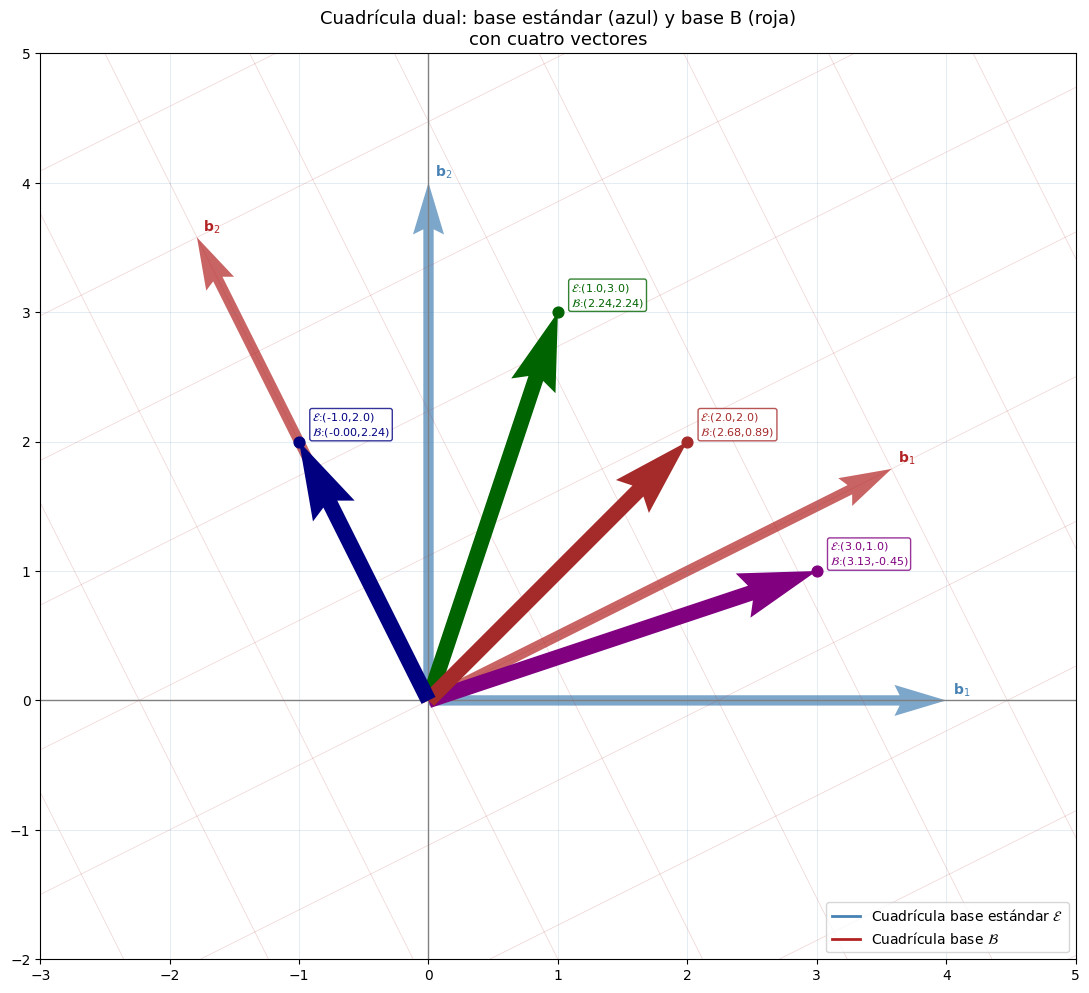


Tabla de coordenadas:
Vector                 Base E                 Base B          
------------------------------------------------------------
[3. 1.]         (3.00, 1.00)       (3.1305, -0.4472)
[1. 3.]         (1.00, 3.00)       (2.2361, 2.2361)
[2. 2.]         (2.00, 2.00)       (2.6833, 0.8944)
[-1.  2.]       (-1.00, 2.00)       (-0.0000, 2.2361)


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración
bv1 = BasisVisualizer([1, 0], [0, 1], name='Estándar')
bv2 = BasisVisualizer([2/np.sqrt(5), 1/np.sqrt(5)], [-1/np.sqrt(5), 2/np.sqrt(5)], name='B')

vectores_demo = [
    np.array([3., 1.]),
    np.array([1., 3.]),
    np.array([2., 2.]),
    np.array([-1., 2.]),
]
colores_v = ['purple', 'darkgreen', 'brown', 'navy']

fig, ax = plt.subplots(figsize=(11, 10))
ax.set_xlim(-3, 5); ax.set_ylim(-2, 5)
ax.set_aspect('equal')
ax.set_title('Cuadrícula dual: base estándar (azul) y base B (roja)\ncon cuatro vectores', fontsize=13)

# Cuadrículas
bv1.draw_grid(ax, xlim=(-3,5), ylim=(-2,5), color='steelblue', alpha=0.2)
bv2.draw_grid(ax, xlim=(-3,5), ylim=(-2,5), color='firebrick', alpha=0.2)
ax.axhline(0, color='gray', lw=1); ax.axvline(0, color='gray', lw=1)

# Vectores
for v, col in zip(vectores_demo, colores_v):
    c_std = bv1.to_basis(v)
    c_B   = bv2.to_basis(v)
    ax.quiver(0,0,v[0],v[1],angles='xy',scale_units='xy',scale=1,
              color=col,width=0.015,zorder=5)
    ax.scatter(*v, color=col, s=60, zorder=10)
    ax.text(v[0]+0.1, v[1]+0.05,
            f'$\\mathcal{{E}}$:({c_std[0]:.1f},{c_std[1]:.1f})\n'
            f'$\\mathcal{{B}}$:({c_B[0]:.2f},{c_B[1]:.2f})',
            color=col, fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2',facecolor='white',alpha=0.8,edgecolor=col))

import matplotlib.lines as mlines
blue_p = mlines.Line2D([], [], color='steelblue', lw=2, label='Cuadrícula base estándar $\\mathcal{E}$')
red_p  = mlines.Line2D([], [], color='firebrick',  lw=2, label='Cuadrícula base $\\mathcal{B}$')
ax.legend(handles=[blue_p, red_p], loc='lower right', fontsize=10)

plt.tight_layout(); plt.show()
print("\nTabla de coordenadas:")
print(f"{'Vector':<15} {'Base E':^20} {'Base B':^25}")
print("-"*60)
for v in vectores_demo:
    ce = bv1.to_basis(v)
    cb = bv2.to_basis(v)
    print(f"{str(v):<15} ({ce[0]:.2f}, {ce[1]:.2f})       ({cb[0]:.4f}, {cb[1]:.4f})")

## 🎓 Reflexión Final y Conclusiones

### Lo que construiste

En esta actividad implementaste un **visualizador de bases** que:

- Dibuja la cuadrícula de cualquier base en $\mathbb{R}^2$.
- Convierte coordenadas entre sistemas de referencia.
- Calcula la representación de transformaciones en cualquier base.
- Demuestra visualmente que la base de autovectores simplifica la transformación.

### Lecciones clave

| Observación visual | Concepto algebraico |
|:---|:---|
| Los vectores son los mismos puntos en ambas cuadrículas | $\mathbf{v} = P[\mathbf{v}]_\mathcal{B}$ |
| Las coordenadas numéricas cambian al cambiar de cuadrícula | $[\mathbf{v}]_\mathcal{B} = P^{-1}\mathbf{v}$ |
| En la base de autovectores, la transformación no mezcla ejes | $A_\mathcal{B} = D$ (diagonal) |
| Elegir la base correcta simplifica enormemente el trabajo | Aplicaciones en PCA, física, etc. |

### 🚀 Extensiones propuestas

Si quieres ir más lejos:

1. **3D:** Extiende el visualizador a $\mathbb{R}^3$ con `mpl_toolkits.mplot3d`.
2. **Animación:** Muestra el cambio de base como una transición animada.
3. **PCA básico:** Aplica el cambio de base a una nube de puntos en 2D (precursor del Análisis de Componentes Principales).
4. **Base Gram-Schmidt:** Implementa el proceso de ortonormalización y compara.

---

> 🎓 *"Una buena base es como una buena perspectiva: no cambia la realidad, pero
> puede hacer que todo sea más claro y comprensible."*

---

👉 **Siguiente capítulo:** Autovalores y autovectores — donde encontrarás sistemáticamente
la mejor base para cualquier transformación.